# SPOTIFY RECOMMENDATION SYSTEM

## PROBLEMA

Serviços de streaming musical usam sistemas de recomendação para sugerir novas músicas aos usuários com base em suas preferências.

Neste projeto vou desenvolver um sistema de recomendação baseado em conteúdo (*Content-Based Recommendation System*), usando características musicais extraídas das faixas do dataset.

## OBJETIVO

Identificar músicas semelhantes a uma música de referência usando atributos musicais - 

- Danceability
- Energy
- Loudness
- Speechiness
- Acousticness
- Instrumentalness
- Liveness
- Valence
- Tempo

## TÉCNICA UTILIZADA

O algoritmo escolhido foi o **Nearest Neighbors**, que recomenda músicas com base na proximidade entre suas características musicais após o processo de escalonamento dos dados.

## RESULTADO ESPERADO

Ao informar o nome de uma música, e opcionalmente o artista, o sistema retorna músicas com características sonoras semelhantes

# RECOMMENDATION MODEL

Nesse notebook vou desenvolver o sistema de recomendacao baseado em similaridade usando o algoritmo `Nearest Neighbors`

## IMPORTAÇÕES

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler 
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

sys.path.append(os.path.abspath(".."))

from functions.recommendation import recommend_by_index

## CARREGAMENTO

In [2]:
df_spotify = pd.read_csv(r'../data/dataset.csv')

In [3]:
display(df_spotify.head(n=5))

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## LIMPEZA

Foram removidos registors com valores ausentes e eliminada a coluna criada durante a exportação do dataset.

In [4]:
df_spotify = df_spotify.dropna()
df_spotify = df_spotify.drop(columns=['Unnamed: 0'])

display(df_spotify.head(n=3))
display(df_spotify.isnull().sum())

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

## FEATURES
O sistema usa 9 atributos musicais, disponibilizados pelo Spotify. Essas variáveis representam características sonoras das músicas e ajudam para medir similaridade entre elas. 

In [5]:
features = ["danceability",
            "energy",
            "loudness",
            "speechiness",
            "acousticness",
            "instrumentalness",
            "liveness",
            "valence",
            "tempo"]

In [6]:
display(df_spotify[features])

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.7150,87.917
1,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.2670,77.489
2,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.1200,76.332
3,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.1430,181.740
4,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.1670,119.949
...,...,...,...,...,...,...,...,...,...
113995,0.172,0.2350,-16.393,0.0422,0.6400,0.928000,0.0863,0.0339,125.995
113996,0.174,0.1170,-18.318,0.0401,0.9940,0.976000,0.1050,0.0350,85.239
113997,0.629,0.3290,-10.895,0.0420,0.8670,0.000000,0.0839,0.7430,132.378
113998,0.587,0.5060,-10.889,0.0297,0.3810,0.000000,0.2700,0.4130,135.960


## ESCALONAMENTO 

Como o Nearest Neighbors usa distancia entre observações, precisei padronizar as variáveis usando o StandardScaler.

Fazendo isso, nenhuma feature domina o cálculo da distância por possuir valores maiores, como acontece com a variável (Tempo)

In [7]:
scaler = StandardScaler()

df_modelagem = df_spotify[features]

df_modelagem_escalado = scaler.fit_transform(df_modelagem)

## TREINAMENTO DO MODELO

Feito o escalonamento, o modelo Nearest Neighbors foi treinado usando a distância Euclidiana para medir a similaridade entre as músicas.

In [8]:
modelo_NN = NearestNeighbors(metric="euclidean")

modelo_NN.fit(df_modelagem_escalado)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


## COMO O ALGORITMO FAZ AS RECOMENDAÇÕES

O Nearest Neighbors não aprende relações entre variáveis como modelos supervisionados. Ele armazena as representações das músicas no espaço das features e, durante uma consulta, calcula quais registros estão mais proximos da musica de referência usando distância Euclidiana

# TESTE DO MODELO

## BUSCA DE VIZINHOS

Nessa etapa selecionei a musica "believer" como referencia e utilizei o modelo treinado para identificar as faixas mais semelhantes com base nas características musicais utilizadas durante o treinamento.

A própria música de teste aparece como primeiro vizinho (distância = 0), sendo as recomendaçoes consideradas a partir do segundo resultado.

In [9]:
indice = df_spotify[df_spotify['track_name'].str.lower() == 'believer'].index[0]

musica = df_modelagem_escalado[indice]

musica = musica.reshape(1, -1)
print(musica)

[[-0.44254771  1.00432443  0.75257455 -0.39299541 -0.9082341  -0.49519846
  -0.61012569 -1.09953729  1.72796823]]


In [10]:
distancias, indices = modelo_NN.kneighbors(musica)
print(distancias)
print(indices)

resultado = df_spotify.iloc[indices[0]][
    ["track_name", "artists", "track_genre"]
]

resultado

[[0.         0.33652989 0.34148182 0.35556721 0.35556721]]
[[27169 27631 27705  5618 63501]]


,track_name,artists,track_genre
27169,Believer,Friction,drum-and-bass
27631,Dying Light,Metrik;ShockOne,drum-and-bass
27705,Thinkin About - T & Sugah Remix,ShockOne;Lee Mvtthews;T & Sugah,drum-and-bass
5618,ninelie,Aimer;Chelly,anime
63501,ninelie,Aimer;Chelly,j-rock


## AVALIAÇÃO DO MODELO

Nessa etapa avalio se as recomendacoes feitas pelo algoritmo apresentam características semelhantes a musica de teste.

In [11]:
resultado_indices = indices[0]

comparacao = df_spotify.iloc[resultado_indices][["track_name",
                                                 "track_genre",
                                                 "danceability",
                                                 "energy",
                                                 "loudness",
                                                 "speechiness",
                                                 "acousticness",
                                                 "instrumentalness",
                                                 "liveness",
                                                 "valence",
                                                 "tempo"]]

comparacao

,track_name,track_genre,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
27169,Believer,drum-and-bass,0.490,0.894,-4.474,0.0431,0.012900,0.002760,0.0974,0.189,173.949
27631,Dying Light,drum-and-bass,0.492,0.867,-4.423,0.0377,0.000966,0.064400,0.1100,0.249,174.032
27705,Thinkin About - T & Sugah Remix,drum-and-bass,0.522,0.861,-3.469,0.0473,0.043600,0.000006,0.1130,0.213,173.958
5618,ninelie,anime,0.462,0.850,-5.558,0.0453,0.025600,0.000019,0.0756,0.206,172.063
63501,ninelie,j-rock,0.462,0.850,-5.558,0.0453,0.025600,0.000019,0.0756,0.206,172.063


## VISUALIZAÇÃO DAS RECOMENDAÇÕES COM PCA

As musicas do dataset são representadas por 9 características musicais, o que dificulta um pouco a visualização.
Para facilitar, utilizei a técnica PCA (Principal Component Analysis), reduzindo os dados para 2 dimensões. 

In [12]:
pca = PCA(n_components=2)

componentes = pca.fit_transform(df_modelagem_escalado)

In [13]:
df_pca = pd.DataFrame(componentes,
                      columns=["PCA1","PCA2"])

display(df_pca.head())

,PCA1,PCA2
0,0.639565,1.081869
1,-3.331079,1.009659
2,-1.387508,-0.206647
3,-3.379290,-0.651670
4,-0.988600,0.255113


In [14]:
print(pca.explained_variance_ratio_)
print(f'{pca.explained_variance_ratio_.sum():.2f}')

[0.31928144 0.15850939]
0.48


### VARIÂNCIA EXPLICADA

As duas PCA preservaram 48% da variabilidade original dos dados.
Existiu perda de informacao durante a reducão de dimensão porem esse resultado ja é suficiente para visualizacao, permitindo observar padrões de proximidade entre as musicas em um espaço de 2 dimensões.

## VISUALIZAÇÃO COM SCATTERPLOT

In [15]:
df_pca['indice_original'] = df_spotify.index

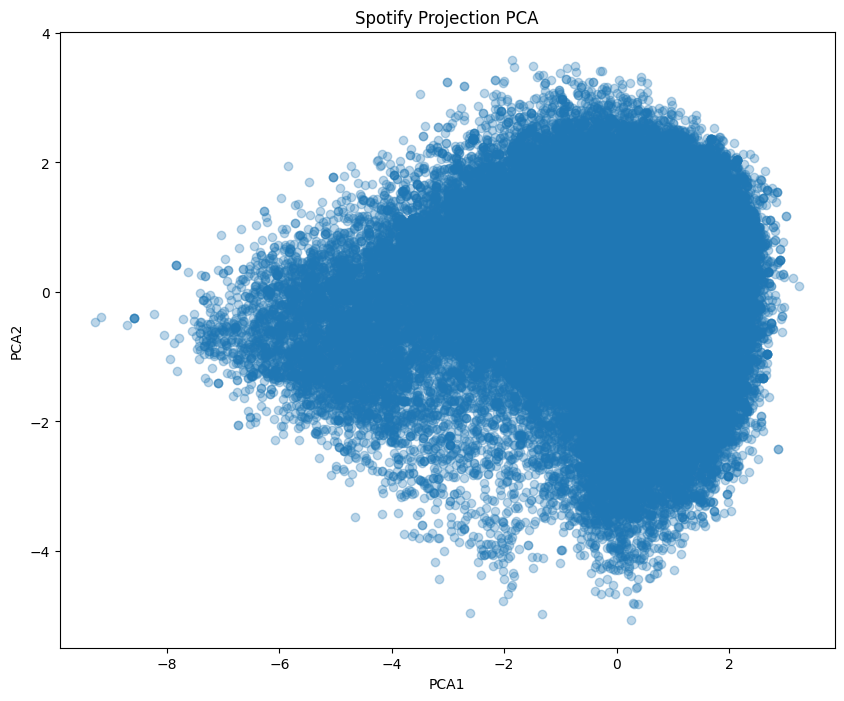

In [16]:
plt.figure(figsize=(10,8))

plt.scatter(x=df_pca["PCA1"],
            y=df_pca["PCA2"],
            alpha=0.3)


plt.title("Spotify Projection PCA")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

### VISUALIZAÇÃO DOS VIZINHOS PROXIMOS COM SCATTERPLOT

Nessa etapa destaquei a musica believer que usei anteriormente para o teste, e suas recomendacões na projeção PCA. Como o Nearest Neighbors usa distância para similaridade, é esperado que as musicas recomendadas estejam proximas a musica original.

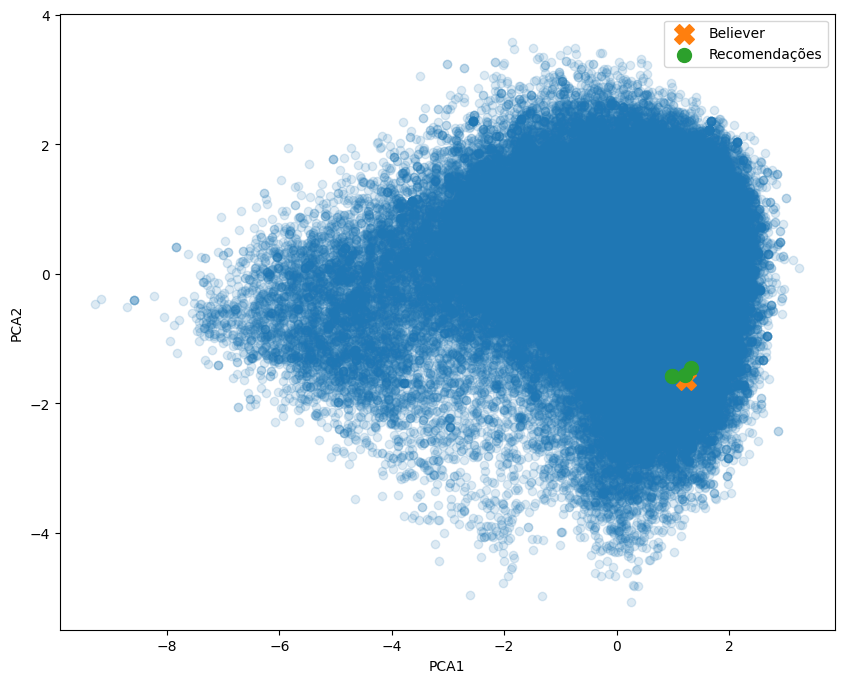

In [17]:
plt.figure(figsize=(10,8))

# SCATTER DE TODAS AS MUSICAS
plt.scatter(
            x=df_pca["PCA1"],
            y=df_pca["PCA2"],
            alpha=0.15)


# SCATTER DA MUSICA TESTE
plt.scatter(
            df_pca.loc[indice, "PCA1"],
            df_pca.loc[indice, "PCA2"],
            s=200,
            marker="X",
            label="Believer")

plt.scatter(
    df_pca.iloc[indices[0][1:]] ["PCA1"],
    df_pca.iloc[indices[0][1:]] ["PCA2"],
    s=100,
    label="Recomendações"
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend()

plt.show()

## INTERPRETAÇÃO DOS RESULTADOS

A análise das recomendações mostrou que as musicas sugeridas apresentam caracteristicas semelhantes com a musica teste (believer).

Além disso, a PCA demonstrou que as recomendações ocupam regiões bem próximas da musica teste, indicando que o algoritmo conseguiu identificar padrões de similaridade entre as musicas.

Esses resultados ajudam a evidenciar que o modelo de recomendações com Nearest Neighbors está funcionando! 

# IMPLEMENTAÇÃO DO SISTEMA DE RECOMENDAÇÃO

Nessa etapa criarei uma funçao para consultar o modelo treinado e retornar recomendações de músicas semelhantes.

## Função de Recomendação

Parâmetros:
- song_name: Nome da música como referência.
- artist (opcional): Artista utilizado para diferenciar músicas com o mesmo nome.
- qtd_musicas_buscar (opcional): Quantidade de músicas que aparecerão como recomendação de similaridade.

Retorno:
- DataFrame contendo as músicas mais semelhantes encontradas pelo modelo.
- Caso a música ou o artista não sejam encontrados, o sistema informa ao usuário.
- Também sao feitas validações para impedir quantidades inválidas de recomendações.

In [18]:
def recommendation_song(song_name,
                        qtd_musicas_buscar=10,
                        artist=""):
    
    procurar_musica = df_spotify[df_spotify["track_name"].str.lower() == song_name.lower().strip()]
    if procurar_musica.empty:
        print(f"A musica ({song_name}) não foi encontrada na base de dados utilizada neste projeto.")
    
    else:
        if not artist: 
            indice = procurar_musica.index[0]
            
            return recommend_by_index(indice=indice,
                               df_modelagem_escalado=df_modelagem_escalado,
                               modelo_NN=modelo_NN,
                               df_spotify=df_spotify,
                               qtd_musicas_buscar=qtd_musicas_buscar)

        else:
             
             condicao = procurar_musica['artists'].str.lower().str.contains(artist.lower().strip())
             
             resultado = procurar_musica[condicao]
            
            
            
             if resultado.empty:
                 print(f"O artista ({artist}) não foi encontrado na base de dados utilizada neste projeto, ou não produziu a música {song_name}.")
             else:
                 indice = resultado.index[0]
                   
                 return recommend_by_index(indice=indice,
                                    df_modelagem_escalado=df_modelagem_escalado,
                                    modelo_NN=modelo_NN,
                                    df_spotify=df_spotify,
                                    qtd_musicas_buscar=qtd_musicas_buscar)

# DEMONSTRAÇÃO DO SISTEMA

In [19]:
recommendation_song(song_name="Shape Of You",
                    artist='Andrew Foy',
                    qtd_musicas_buscar=-10)

ValueError: NÃO É PERMITIDO A QUANTIDADE DE RECOMENDAÇÕES MENORES QUE 1 E MAIORES QUE 30

In [20]:
recommendation_song(song_name="believer",
                    qtd_musicas_buscar=10)

,track_name,artists,album_name,track_genre
27169,Believer,Friction,Believer,drum-and-bass
27631,Dying Light,Metrik;ShockOne,Ex Machina,drum-and-bass
27705,Thinkin About - T & Sugah Remix,ShockOne;Lee Mvtthews;T & Sugah,Thinkin About (T & Sugah Remix),drum-and-bass
27830,Better Times Are Coming - Keeno Remix,Fred V & Grafix;Josie,Unrecognisable,drum-and-bass
27261,Endorphins - Sub Focus Vs. Fred V & Grafix Remix,Sub Focus;Alex Clare;Nicolaas Douwma;Fred V;Gr...,Endorphins,drum-and-bass
27070,Ghost Assassin - Original Mix,Maduk;Veela,Ghost Assassin EP,drum-and-bass
27846,Go,Maduk;Lachi,Liquicity Drum & Bass 2019,drum-and-bass
27100,Everybody Loves The Sunshine,Netsky;Daddy Waku;Chantal Kashala,Second Nature,drum-and-bass
27453,By Your Side,Friction;Flowidus;Raphaella,By Your Side,drum-and-bass
27853,Climbing The Walls,Fred V;Paul Dowling,Climbing The Walls,drum-and-bass


In [21]:
recommendation_song(song_name="Sie - Best Of VRR",
                    qtd_musicas_buscar=5)

,track_name,artists,album_name,track_genre
78916,Wieder auffer Tanze,Talstrasse 3-5,Wieder auffer Tanze,party
89911,Reggaetón Lento (Remix),CNCO;Little Mix,Glory Days (Expanded Edition),reggaeton
65464,Alcohol-Free,TWICE,Taste of Love,k-pop
65695,Same Scent,ONEUS,MALUS,k-pop
86766,Suerte!,Árbol,GUAU!,punk


In [22]:
recommendation_song(song_name="Litt Sister Anthem",
                    qtd_musicas_buscar=2)

,track_name,artists,album_name,track_genre
66793,"Featuring Mixx Master Lee, Red Rum & J. Smoov ...",Mixx Master Lee,The Mississippi Cha Cha Slide A.K.A. STOMP 2007,kids
66928,Can't Have Rainbows,Hip Hop Harry,"Hip Hop Harry, Vol. 3",kids


## ANÁLISE DOS RESULTADOS

Realizei testes com diferentes musicas para ver a capacidade do sistema em identificar faixas semelhantes.

De forma geral, as recomendações apresentaram características próximas as músicas consultadas, indicando que o modelo conseguiu encontrar padrões utilizando as features selecionadas.

Também observei que algumas músicas aparecem múltiplas vezes no dataset, associadas a diferentes álbuns ou gêneros musicais.

Essa característica pode influenciar algumas recomendações e representa uma limitação dos dados utilizados.

Além disso, foram implementadas validações para entrada do usuário, permitindo consultas por artista e limitando a quantidade máxima de recomendações que o sistema retorna.